# Exploratory Data Analysis

This notebook explores the relationship between physical inactivity and happiness across 131 countries.
All visualizations are saved to the `reports/` folder for use in the IEEE report and presentations.

**Contents:**
1. Load cleaned dataset
2. Scatter plot — Inactivity vs Happiness
3. Correlation matrix
4. Happiness score by region (box plot)
5. Top 10 happiest and least happy countries
6. Physical inactivity by region

## 1. Load Cleaned Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the merged and cleaned dataset produced by 01_data_exploration.ipynb
df = pd.read_csv('../data/merged_clean.csv')

print("Dataset shape:", df.shape)
print("Regions:", df['Region'].nunique())
df.head()

Dataset shape: (131, 27)
Regions: 10


,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),...,World Bank Income Group,GDP per capita (INT$),"Physical Inactivity, Adolescents Aged 11-17 (%), Male","Physical Inactivity, Adolescents Aged 11-17 (%), Female","Physical Inactivity, Adults Aged 18+ (%), Male","Physical Inactivity, Adults Aged 18+ (%), Female","Physical Inactivity, Adults Aged 70+ (%), Male","Physical Inactivity, Adults Aged 70+ (%), Female",Avg Inactivity Adults,Avg Inactivity Adolescents
0,Switzerland,Western Europe,1,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,...,HIGH,NaN,83.0,89.0,22.000,26.0000,34.000000,41.000000,24.00000,86.0
1,Iceland,Western Europe,2,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,...,HIGH,NaN,75.0,85.0,24.875,32.5625,35.669643,45.151786,28.71875,80.0
2,Denmark,Western Europe,3,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,...,HIGH,NaN,82.0,87.0,26.000,31.0000,39.000000,46.000000,28.50000,84.5
3,Norway,Western Europe,4,7.522,0.03880,1.45900,1.33095,0.88521,0.66973,0.36503,...,HIGH,NaN,79.0,89.0,30.000,34.0000,44.000000,50.000000,32.00000,84.0
4,Canada,North America,5,7.427,0.03553,1.32629,1.32261,0.90563,0.63297,0.32957,...,HIGH,NaN,71.0,82.0,26.000,31.0000,39.000000,47.000000,28.50000,76.5


## 2. Scatter Plot — Physical Inactivity vs Happiness

Each point represents one country, colored by region.
This gives a first visual impression of the relationship between inactivity and happiness.

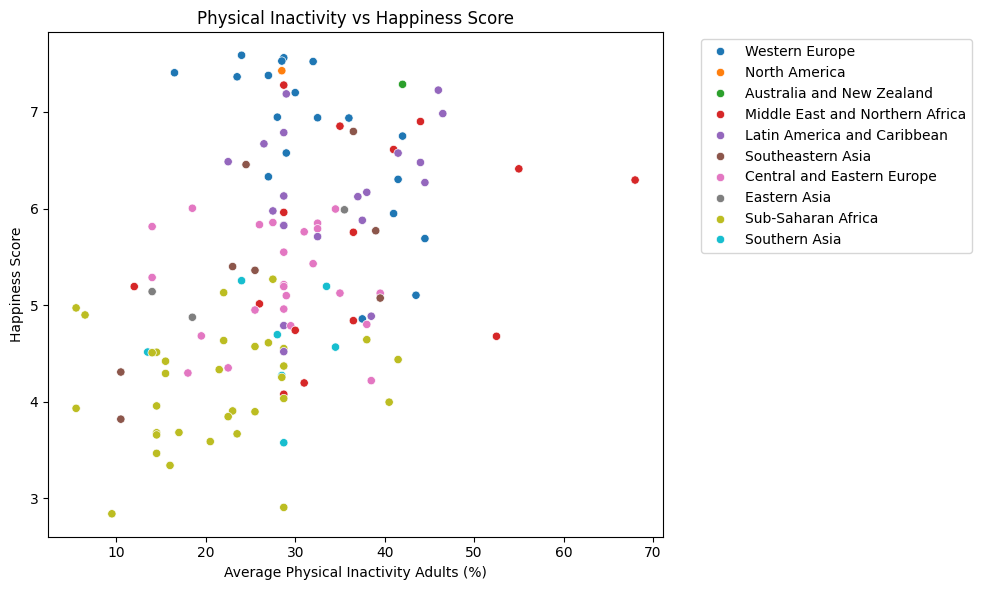

In [2]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Avg Inactivity Adults', y='Happiness Score', hue='Region')

plt.title('Physical Inactivity vs Happiness Score')
plt.xlabel('Average Physical Inactivity Adults (%)')
plt.ylabel('Happiness Score')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('../reports/inactivity_vs_happiness.png', dpi=150)
plt.show()

## 3. Correlation Matrix

Shows pairwise correlations between happiness score and all key features.
Helps identify which variables are most strongly associated with happiness,
and guides feature selection for the regression models.

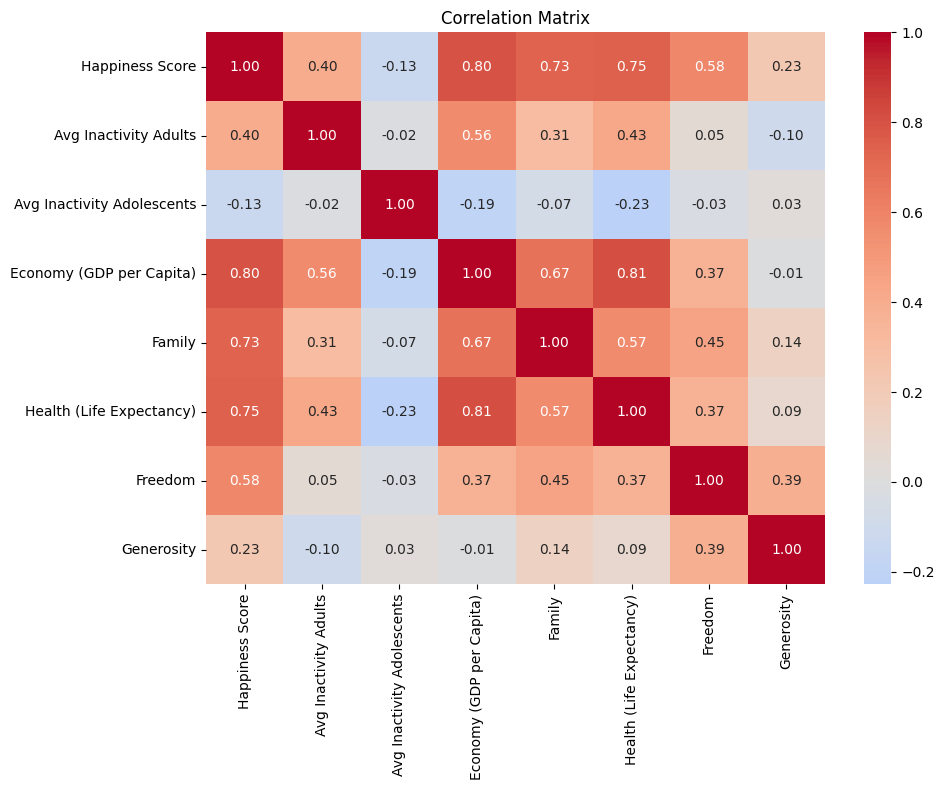

In [3]:
corr_cols = [
    'Happiness Score',
    'Avg Inactivity Adults',
    'Avg Inactivity Adolescents',
    'Economy (GDP per Capita)',
    'Family',
    'Health (Life Expectancy)',
    'Freedom',
    'Generosity'
]

corr = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.savefig('../reports/correlation_matrix.png', dpi=150)
plt.show()

## 4. Happiness Score by Region

Box plot showing the distribution of happiness scores across world regions.
This reveals regional patterns — e.g. Western Europe tends to score higher than Sub-Saharan Africa.

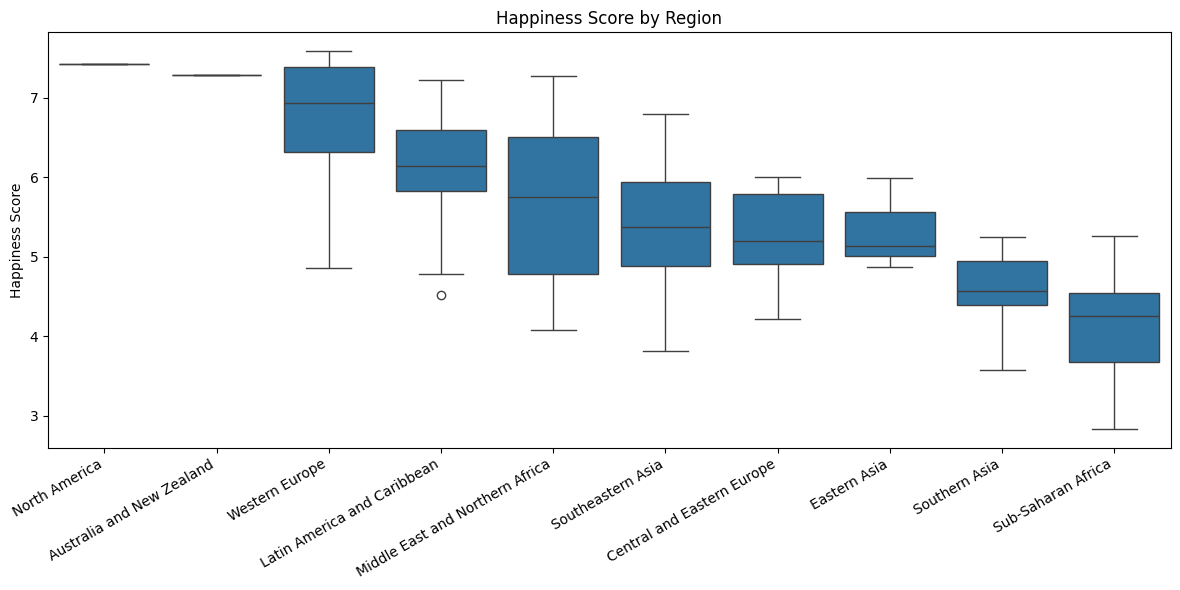

In [4]:
# Sort regions by median happiness score for cleaner visualization
region_order = df.groupby('Region')['Happiness Score'].median().sort_values(ascending=False).index

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Region', y='Happiness Score', order=region_order)

plt.title('Happiness Score by Region')
plt.xlabel('')
plt.ylabel('Happiness Score')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../reports/happiness_by_region.png', dpi=150)
plt.show()

## 5. Top 10 Happiest and Least Happy Countries

Bar charts showing the extreme ends of the happiness spectrum.
Useful for identifying patterns — are the happiest countries also the most active?

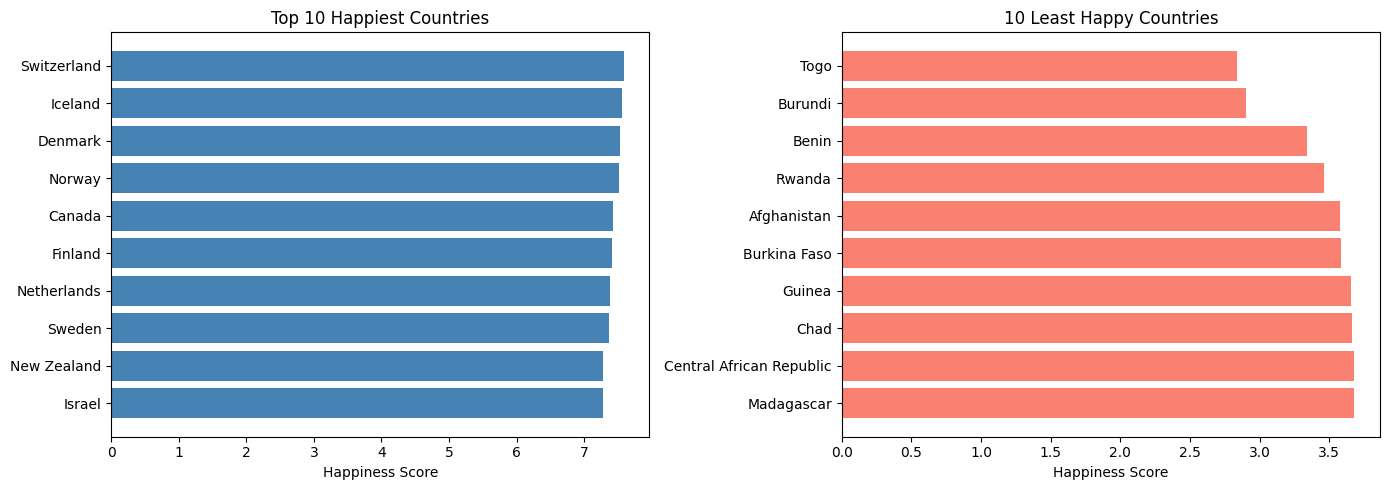

Top 10:
    Country  Happiness Score  Avg Inactivity Adults
Switzerland            7.587               24.00000
    Iceland            7.561               28.71875
    Denmark            7.527               28.50000
     Norway            7.522               32.00000
     Canada            7.427               28.50000
    Finland            7.406               16.50000
Netherlands            7.378               27.00000
     Sweden            7.364               23.50000
New Zealand            7.286               42.00000
     Israel            7.278               28.71875

Bottom 10:
                 Country  Happiness Score  Avg Inactivity Adults
                    Togo            2.839                9.50000
                 Burundi            2.905               28.71875
                   Benin            3.340               16.00000
                  Rwanda            3.465               14.50000
             Afghanistan            3.575               28.71875
            Burkin

In [5]:
top10 = df.nlargest(10, 'Happiness Score')[['Country', 'Happiness Score', 'Avg Inactivity Adults']]
bottom10 = df.nsmallest(10, 'Happiness Score')[['Country', 'Happiness Score', 'Avg Inactivity Adults']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top 10
axes[0].barh(top10['Country'], top10['Happiness Score'], color='steelblue')
axes[0].set_title('Top 10 Happiest Countries')
axes[0].set_xlabel('Happiness Score')
axes[0].invert_yaxis()

# Bottom 10
axes[1].barh(bottom10['Country'], bottom10['Happiness Score'], color='salmon')
axes[1].set_title('10 Least Happy Countries')
axes[1].set_xlabel('Happiness Score')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('../reports/top_bottom_countries.png', dpi=150)
plt.show()

print("Top 10:")
print(top10.to_string(index=False))
print()
print("Bottom 10:")
print(bottom10.to_string(index=False))

## 6. Physical Inactivity by Region

Shows average inactivity rates per region for both adults and adolescents.
Helps understand whether inactivity differences between regions could explain happiness differences.

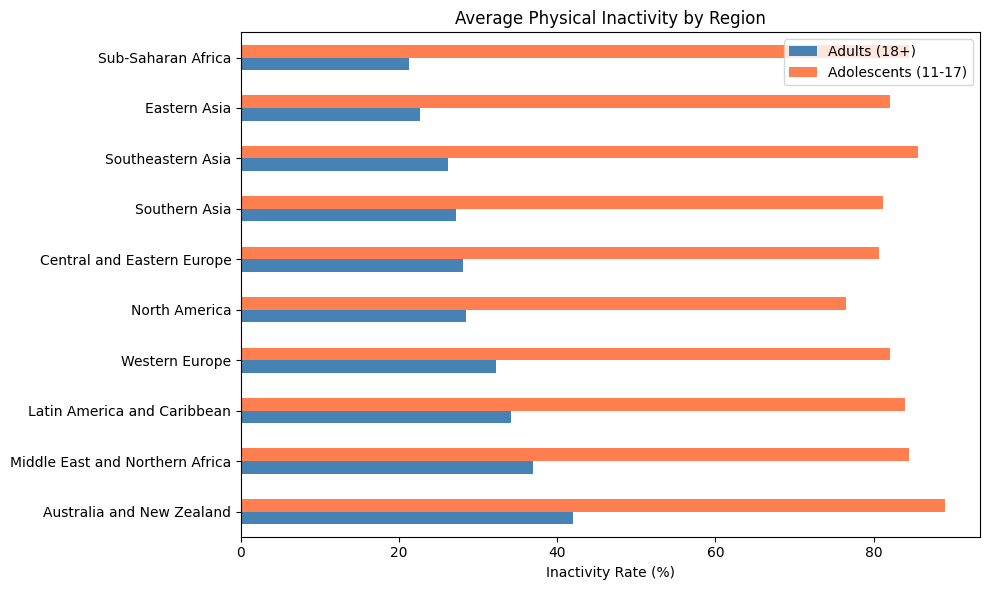

In [6]:
# Calculate mean inactivity per region
inactivity_region = df.groupby('Region')[['Avg Inactivity Adults', 'Avg Inactivity Adolescents']].mean()
inactivity_region = inactivity_region.sort_values('Avg Inactivity Adults', ascending=False)

inactivity_region.plot(kind='barh', figsize=(10, 6), color=['steelblue', 'coral'])

plt.title('Average Physical Inactivity by Region')
plt.xlabel('Inactivity Rate (%)')
plt.ylabel('')
plt.legend(['Adults (18+)', 'Adolescents (11-17)'])
plt.tight_layout()
plt.savefig('../reports/inactivity_by_region.png', dpi=150)
plt.show()